<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/Final_EDA_Balancing_Methodology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WHSAT EDA and Balancing Notebook
Implements stratified summaries, class imbalance handling, focal loss utilities, and Bayesian class weighting preparation according to the methodology.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn


In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/IHMStefanini_industrial_safety_and_health_database_with_accidents_description.csv")
df = df.rename(columns={'Data':'date','Genre':'gender','Accident Level':'accident_level','Potential Accident Level':'potential_accident_level','Critical Risk':'critical_risk','Description':'description'})
severity_map={'I':1,'II':2,'III':3,'IV':4,'V':5}
df['severity']=df['accident_level'].map(severity_map)
df['potential_severity']=df['potential_accident_level'].map(severity_map)
df['near_miss_gap']=df['potential_severity']-df['severity']
df=df.dropna(subset=['severity'])
df['severity_label']=df['severity']-1
print(df[['severity','potential_severity','near_miss_gap']].head())
print(df[['severity','potential_severity','near_miss_gap']].tail())


   severity  potential_severity  near_miss_gap
0         1                 4.0            3.0
1         1                 4.0            3.0
2         1                 3.0            2.0
3         1                 1.0            0.0
4         4                 4.0            0.0
     severity  potential_severity  near_miss_gap
420         1                 3.0            2.0
421         1                 2.0            1.0
422         1                 2.0            1.0
423         1                 2.0            1.0
424         1                 2.0            1.0


In [ ]:
# Stratified summaries
print('Severity Distribution\t')
print(df['severity'].value_counts().sort_index())
print('\t')
print('Severity by Critical Risk\t')
print(pd.crosstab(df['critical_risk'],df['severity']).head())
print('\t')
print(pd.crosstab(df['critical_risk'],df['severity']).tail())
print('\t')
print('Severity proportions\t')
print(df['severity'].value_counts(normalize=True).sort_index())


Severity Distribution	
severity
1    316
2     40
3     31
4     30
5      8
Name: count, dtype: int64
	
Severity by Critical Risk	
severity                             1  2  3  4  5
critical_risk                                     
\nNot applicable                     0  0  0  1  0
Bees                                10  0  0  0  0
Blocking and isolation of energies   3  0  0  0  0
Burn                                 0  0  1  0  0
Chemical substances                 15  2  0  0  0
	
severity                        1  2  3  4  5
critical_risk                                
Suspended Loads                 4  0  1  1  0
Traffic                         1  0  0  0  0
Vehicles and Mobile Equipment   5  1  0  1  1
Venomous Animals               16  0  0  0  0
remains of choco                2  2  0  2  1
	
Severity proportions	
severity
1    0.743529
2    0.094118
3    0.072941
4    0.070588
5    0.018824
Name: proportion, dtype: float64


In [ ]:
# Stratified train-test split
train_df,test_df=train_test_split(df,test_size=0.2,stratify=df['severity_label'],random_state=42)
print(train_df['severity_label'].value_counts(normalize=True).sort_index())
print(test_df['severity_label'].value_counts(normalize=True).sort_index())


severity_label
0    0.744118
1    0.094118
2    0.073529
3    0.070588
4    0.017647
Name: proportion, dtype: float64
severity_label
0    0.741176
1    0.094118
2    0.070588
3    0.070588
4    0.023529
Name: proportion, dtype: float64


In [ ]:
# Class weights for imbalanced data
classes=np.unique(df['severity_label'])
weights=compute_class_weight(class_weight='balanced',classes=classes,y=df['severity_label'])
class_weights=dict(zip(classes,weights))
print(class_weights)


{np.int64(0): np.float64(0.2689873417721519), np.int64(1): np.float64(2.125), np.int64(2): np.float64(2.7419354838709675), np.int64(3): np.float64(2.8333333333333335), np.int64(4): np.float64(10.625)}


In [ ]:
# Focal Loss for Transformer models
class FocalLoss(nn.Module):
    def __init__(self,alpha=None,gamma=2.0):
        super().__init__()
        self.alpha=alpha
        self.gamma=gamma
    def forward(self,inputs,targets):
        ce=nn.functional.cross_entropy(inputs,targets,weight=self.alpha,reduction='none')
        pt=torch.exp(-ce)
        loss=((1-pt)**self.gamma)*ce
        return loss.mean()

alpha=torch.tensor(weights,dtype=torch.float32)
criterion=FocalLoss(alpha=alpha,gamma=2.0)
print('Focal loss ready for DistilBERT/BERT training.')


Focal loss ready for DistilBERT/BERT training.


In [ ]:
# Bayesian class weighting preparation
# These weights can be incorporated into the likelihood term
# of Bayesian logistic or ordinal models.

bayesian_class_weights = {int(k):float(v) for k,v in class_weights.items()}
print(bayesian_class_weights)


{0: 0.2689873417721519, 1: 2.125, 2: 2.7419354838709675, 3: 2.8333333333333335, 4: 10.625}


          count  mean_near_miss_gap
severity                           
1           253            1.739130
2            32            1.406250
3            25            0.960000
4            24            0.291667
5             6            0.000000


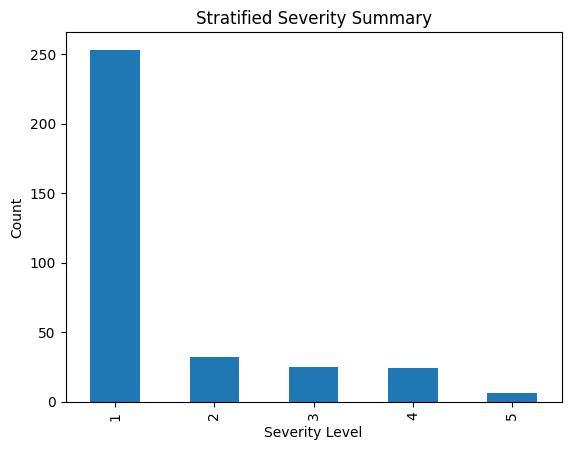

In [ ]:
# Example ordinal severity summaries
summary=train_df.groupby('severity').agg(
    count=('severity','count'),
    mean_near_miss_gap=('near_miss_gap','mean')
)
print(summary)
summary['count'].plot(kind='bar')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.title('Stratified Severity Summary')
plt.show()
